# K-Nearest Neighbors Regressor

**Owner: Student 2 | Review 1 - Regression Track**

In [1]:
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.model_selection import train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder, RobustScaler

SEED = 42
sns.set_theme(style="whitegrid", palette="colorblind")
repo_root = next(
    (parent for parent in (Path.cwd(), *Path.cwd().parents)
     if (parent / "data" / "health_insurance.csv").exists()),
    None,
)
if repo_root is None:
    raise FileNotFoundError("Run this notebook from inside the ML-301 repository.")

raw_df = pd.read_csv(repo_root / "data" / "health_insurance.csv")
df = raw_df.drop_duplicates().copy()
X = df.drop(columns="claim")
y = df["claim"]
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.20, random_state=SEED)

numeric_features = X_train.select_dtypes(include=np.number).columns.tolist()
categorical_features = X_train.select_dtypes(exclude=np.number).columns.tolist()
X_train = X_train.copy()
X_test = X_test.copy()
for frame in (X_train, X_test):
    frame["age_bmi_interaction"] = frame["age"] * frame["bmi"]
numeric_features.append("age_bmi_interaction")

preprocessor = ColumnTransformer([
    ("numeric", Pipeline([
        ("imputer", SimpleImputer(strategy="median")),
        ("scaler", RobustScaler()),
    ]), numeric_features),
    ("categorical", Pipeline([
        ("imputer", SimpleImputer(strategy="most_frequent")),
        ("encoder", OneHotEncoder(handle_unknown="ignore", drop="first", sparse_output=False)),
    ]), categorical_features),
])

results_dir = repo_root / "student_work" / "student_2" / "results"
results_dir.mkdir(parents=True, exist_ok=True)
print(f"Removed {raw_df.duplicated().sum():,} duplicates; train={len(X_train):,}, test={len(X_test):,}")

Removed 1,096 duplicates; train=11,123, test=2,781


In [2]:
from sklearn.model_selection import GridSearchCV
from sklearn.neighbors import KNeighborsRegressor

search = GridSearchCV(
    Pipeline([("preprocessor", preprocessor), ("regressor", KNeighborsRegressor(n_jobs=-1))]),
    {"regressor__n_neighbors": [5, 11, 21], "regressor__weights": ["uniform", "distance"]},
    scoring="r2", cv=5, n_jobs=-1,
)
search.fit(X_train, y_train)
model = search.best_estimator_
model_name = "KNN Regressor"
result_file = "10_knn_regressor.csv"
cv_r2 = search.best_score_
print("Best parameters:", search.best_params_)
print("Best 5-fold CV R2:", round(cv_r2, 4))

Best parameters: {'regressor__n_neighbors': 5, 'regressor__weights': 'distance'}
Best 5-fold CV R2: 0.9486


,Model,R2,RMSE,MAE,CV_R2
0,KNN Regressor,0.959,2470.085,719.862,0.949


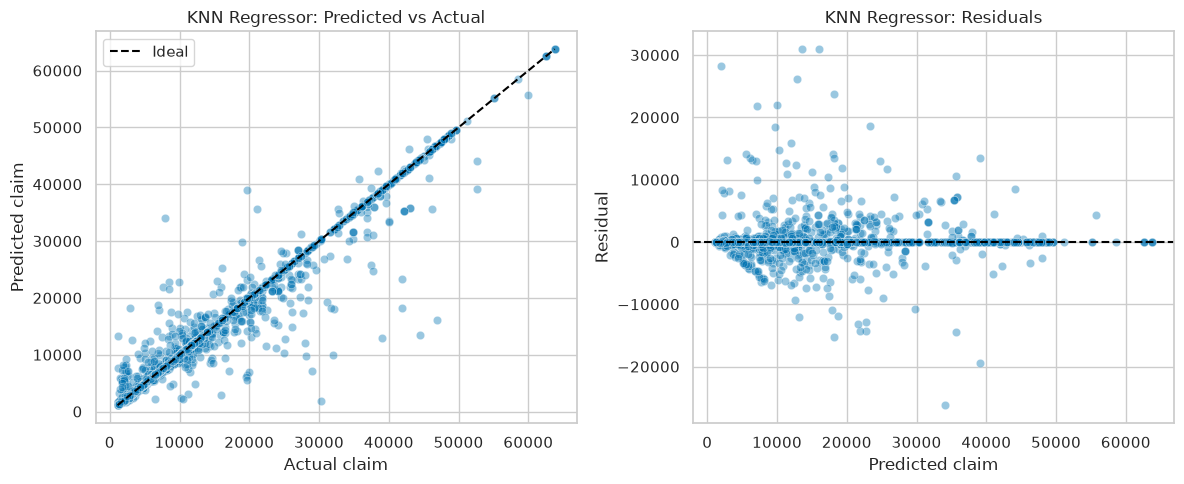

In [3]:
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score

y_pred = model.predict(X_test)
metrics = pd.DataFrame({
    "Model": [model_name],
    "R2": [r2_score(y_test, y_pred)],
    "RMSE": [np.sqrt(mean_squared_error(y_test, y_pred))],
    "MAE": [mean_absolute_error(y_test, y_pred)],
    "CV_R2": [cv_r2],
})
display(metrics.round(3))
metrics.to_csv(results_dir / result_file, index=False)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))
sns.scatterplot(x=y_test, y=y_pred, alpha=0.4, ax=axes[0])
limits = [min(y_test.min(), y_pred.min()), max(y_test.max(), y_pred.max())]
axes[0].plot(limits, limits, "--", color="black", label="Ideal")
axes[0].set(title=f"{model_name}: Predicted vs Actual", xlabel="Actual claim", ylabel="Predicted claim")
axes[0].legend()
sns.scatterplot(x=y_pred, y=y_test - y_pred, alpha=0.4, ax=axes[1])
axes[1].axhline(0, linestyle="--", color="black")
axes[1].set(title=f"{model_name}: Residuals", xlabel="Predicted claim", ylabel="Residual")
plt.tight_layout()
plt.show()
assert np.isfinite(metrics[["R2", "RMSE", "MAE"]].to_numpy()).all()

### Interpretation

K and weighting are tuned after robust scaling because nearest-neighbor distances are scale-sensitive.